# Structuring Recipe Reviews Through Qualitative Tagging Assignment
**Author:** Ian Auger  
**Course:** DSCI 632

### Abstract

Online recipe platforms suffer from "information density" where critical qualitative signals (taste issues, prep difficulty) are buried in millions of free-text reviews. This project develops a scalable multi-label tagging system using a Transformer-based Zero-Shot baseline to generate "Silver Labels" for training a distributed Word2Vec centroid classifier in PySpark. We demonstrate an iterative Active Learning approach to reach a 60,000-sample ground truth, successfully resolving semantic gaps in minority critique classes.

In [ ]:
# Import libraries

import sys
from pathlib import Path
from pyspark.sql import functions as F
from pyspark.ml.feature import Word2Vec, Word2VecModel, NGram, Tokenizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Repository Root Setup
p = Path.cwd().resolve()
while p != p.parent and not (p / "src").exists():
    p = p.parent
if str(p) not in sys.path:
    sys.path.insert(0, str(p))

# Custom Modules
from src.config import load_settings
from src.spark.session import get_spark

# Initialize Settings and Spark
s = load_settings(prefer_latest_run=True)
spark = get_spark(app_name="00_project_report", debug=True)


your 131072x1 screen size is bogus. expect trouble
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/06 21:03:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Introduction & Objectives
User-generated recipe reviews contain rich, multidimensional signals regarding taste, process, and ingredient reliability. However, these insights are embedded in unstructured free text. Traditional statistical measures like TF-IDF or Bag-of-Words (BOW) often fail to capture the semantic nuances such as negation or intensity that are required for high-level qualitative analysis. 

The objective of this project is to develop a scalable multi-label tagging system that transforms raw review text into structured feedback. To achieve this, I employ a **Transformer-based Zero-Shot baseline** to generate a ground-truth dataset, which is then used to train a distributed **Word2Vec-based centroid classifier** in PySpark. This allows for the high-throughput labeling of 1.4 million reviews while maintaining semantic accuracy.

### 1.1 Qualitative Taxonomy (v1)
The taxonomy consists of 17 tags across 6 thematic groups, designed to capture both "Success" and "Risk" signals.

| Group | Tag ID | Description | Polarity |
| :--- | :--- | :--- | :--- |
| **Taste** | `too_salty`, `too_sweet`, `too_acidic`, `too_spicy`, `bland_lacks_flavor`, `delicious_tasty` | Feedback on seasoning, heat, and overall flavor profile. | Mixed |
| **Texture** | `dry`, `mushy_soggy`, `crispy_crunchy`, `moist_tender` | Evaluation of mouthfeel, doneness, and structural integrity. | Mixed |
| **Process** | `easy_quick`, `time_consuming_complex` | Difficulty level and efficiency of the preparation steps. | Mixed |
| **Ingredients**| `substitution_modification`, `ingredient_issue` | Reviewer-led changes vs. inherent recipe ratio problems. | Neutral/Neg |
| **Outcome** | `would_make_again`, `would_not_make_again`, `family_hit` | Intent for future use and external validation by others. | Mixed |

## 2. Exploratory Data Analysis (EDA)

Before applying any semantic models, I performed extensive EDA to understand the distribution of the Food.com review corpus and to establish a threshold for "Informative" content.

### 2.1 The "Informative Review" Filter

To ensure each review provides enough context for stable Word2Vec embeddings, I analyzed the distribution of token counts.

- **Informative Floor (15 tokens):** I established a minimum threshold to exclude short, low-signal reviews (e.g., "Thanks!") that lack the "Subject-Modifier" pairs required for thematic tagging.
- **Semantic Ceiling (120 tokens):** While the corpus contains a long tail extending to 1,303 tokens, the 95th percentile sits at 118 tokens.
- **Pruning Decision:** I implemented a ceiling at 120 tokens to mitigate dilution. In a vector space where document vectors are derived by averaging, extreme length washes out specific critiques (e.g., "too salty").

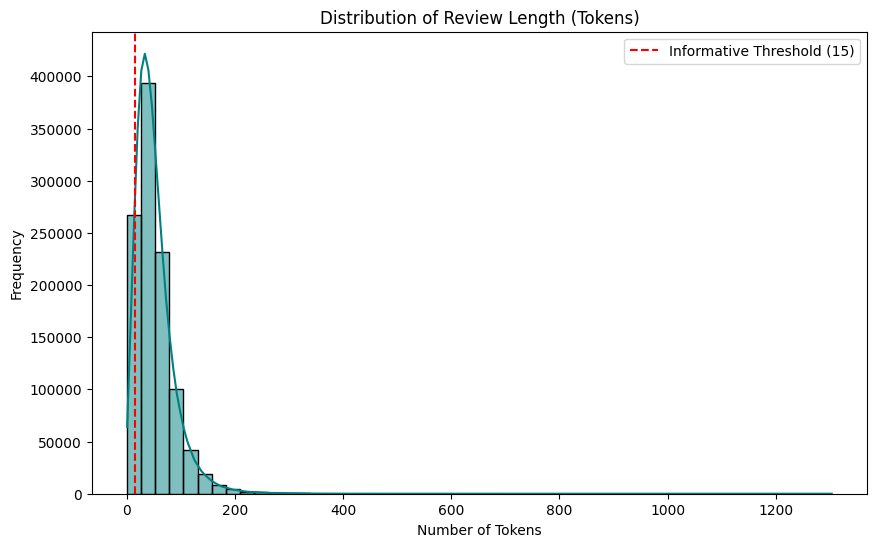

Reviews meeting 15-token threshold: 979,531
Review Length Percentiles:
 count    1.070664e+06
mean     5.189609e+01
std      3.629787e+01
min      1.000000e+00
25%      2.800000e+01
50%      4.400000e+01
75%      6.700000e+01
90%      9.600000e+01
95%      1.180000e+02
99%      1.780000e+02
max      1.303000e+03
Name: token_count, dtype: float64
95th Percentile limit: 118.00 tokens


In [ ]:
gold_reviews = spark.read.parquet(s.gold_reviews_path)

# Calculate token counts for cleaned reviews
reviews_with_length = gold_reviews.withColumn(
    "token_count", 
    F.size(F.split(F.col("review_clean"), " "))
)

# Aggregate for plotting
length_dist = reviews_with_length.select("token_count").toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(length_dist['token_count'], bins=50, kde=True, color='teal')
plt.axvline(15, color='red', linestyle='--', label='Informative Threshold (15)')
plt.title("Distribution of Review Length (Tokens)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Reviews meeting 15-token threshold: {reviews_with_length.filter((F.col('token_count') >= 15)).count():,}")

# Calculate percentiles for review length
stats = length_dist['token_count'].describe(percentiles=[.25, .5, .75, .90, .95, .99])
print("Review Length Percentiles:\n", stats)

# Filter out the top 5% longest reviews
upper_limit = stats['95%']
print(f"95th Percentile limit: {upper_limit:.2f} tokens")

print(f"Reviews within 95th percentile: {reviews_with_length.filter(F.col("token_count") <= upper_limit).count():,}")

### 2.2 Rating Distribution and Semantic Bleed

A primary challenge identified during EDA was the heavy skew toward positive ratings.

- **The "Success Cluster":** Approximately 94% of the dataset consists of 4 and 5-star reviews.
- **Implication for MLC:** This skew makes it statistically easier to identify positive tags (e.g., delicious_tasty) while making "Risk Signals" (e.g., too_acidic) minority classes. Class imbalance will require targeted sampling of keywords associated with risk signals so that they are adequetley represented in the zero-shot labeling population and the Word2Vec models have a reliable centroid to reference. 

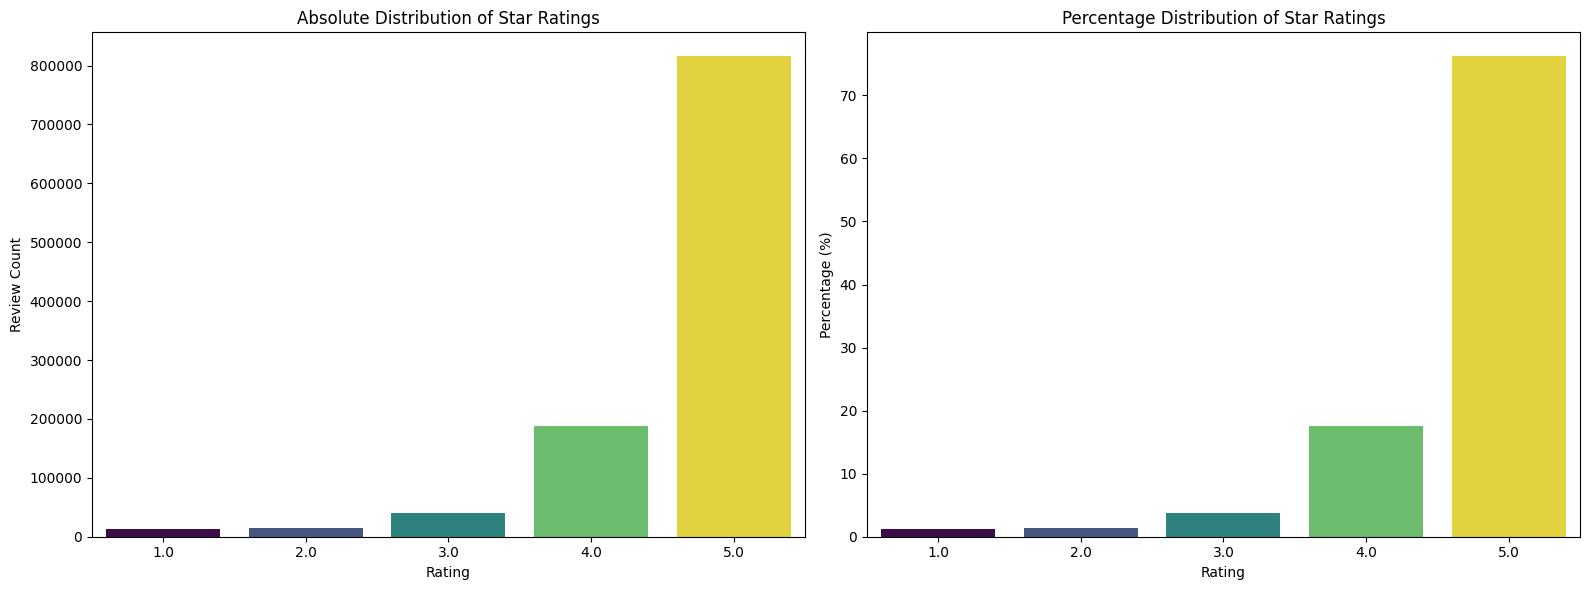

Success Cluster (4-5 Stars): 93.67%


In [10]:
rating_counts = gold_reviews.groupBy("rating").count().orderBy("rating").toPandas()
rating_counts['percent'] = (rating_counts['count'] / rating_counts['count'].sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolute Counts
sns.barplot(ax=ax1, x='rating', y='count', data=rating_counts, hue='rating', palette='viridis', legend=False)
ax1.set_title("Absolute Distribution of Star Ratings")
ax1.set_xlabel("Rating")
ax1.set_ylabel("Review Count")

# Percentages
sns.barplot(ax=ax2, x='rating', y='percent', data=rating_counts, hue='rating', palette='viridis', legend=False)
ax2.set_title("Percentage Distribution of Star Ratings")
ax2.set_xlabel("Rating")
ax2.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

# Success Cluster Calculation
success_pct = rating_counts[rating_counts['rating'] >= 4]['percent'].sum()
print(f"Success Cluster (4-5 Stars): {success_pct:.2f}%")

### 2.3 N-Gram Analysis & Preprocessing Justification

I performed a frequency analysis of bigrams to validate the necessity of the StopWordsRemover stage and help calibrate the Word2Vec window size.

- **Syntactic Noise:** The top bigrams (e.g., "i used," "it was," "thanks for") are almost entirely composed of high-frequency "glue" words that carry zero culinary or process-related information.
- **Stop Word Strategy:** This noise provides the empirical justification for aggressive stopword removal. However, I modified the default list to keep negations (e.g., "not," "no"). Because Word2Vec captures relationships, "not salty" and "too salty" must be distinguishable to prevent the model from incorrectly assigning risk tags to positive feedback.
- **Window Size Choice:** The prevalence of these shorter token pairings suggests that traditional bigram analysis lacks the semantic context to empower a model to understand relationships between larger groupings. I opt for a window size of 3 to enable the capturing of noun-verb-adjective groups (e.g., "fish was bland," "chicken is moist") while maintaining enough focus to ensure individual token weight is not diluted by distant, unrelated context. 

In [ ]:
# Tokenize the cleaned text
tokenizer = Tokenizer(inputCol="review_clean", outputCol="words")
words_df = tokenizer.transform(gold_reviews)

# Generate Bigrams
ngram = NGram(n=2, inputCol="words", outputCol="bigrams")
bigrams_df = ngram.transform(words_df)

# Count top bigrams
top_bigrams = bigrams_df.select(F.explode("bigrams").alias("bigram")) \
    .groupBy("bigram") \
    .count() \
    .orderBy(F.desc("count")) \
    .limit(10) \
    .toPandas()

# Display results
print("Top 10 Bigrams in Corpus:")
print(top_bigrams)

Top 20 Bigrams in Corpus:
         bigram   count
0        i used  250261
1        it was  230639
2    thanks for  183984
3   this recipe  177169
4        of the  172816
5        i made  167709
6        in the  167180
7       this is  163106
8       to make  157131
9      this was  154169
10   the recipe  153522
11        and i  140800
12      for the  137908
13       didn t  129157
14       and it  126220
15        for a  123570
16     a little  119188
17        i had  115262
18       i will  111563
19         so i  110625


## 3. Methodology: Semantic Tagging & Centroid Logic

The core of this tagging system is the transformation of unstructured review text into a dense, $300$-dimensional vector space where semantic proximity correlates to culinary themes.

### 3.1 Foundational Vector Space: Word2Vec

Rather than treating tokens as isolated indices, I employ the Word2Vec paradigm to learn distributed representations from the entire review corpus. That is, the cleaned review text is vectorized so that it can be measured relationally against the average centroids from the transformer labeled dataset. 

- **Semantic Context:** This approach ensures that terms like "salty," "brine," and "sodium" are mathematically proximal, allowing the model to recognize "risk signals" even when specific keywords vary.
- **Hyperparameter Selection:** Following rigorous experimentation, the model utilizes a vector size of 300 and a window size of 3. The expanded window size is critical for capturing local syntactic relationships, such as a subject and its culinary modifier (e.g., "chicken was dry").
- **Context Window:** The window size of 3 captures local "Subject-Modifier" triplets (e.g., "sauce was salty") while minimizing the topical weight that can cause different culinary concepts to bleed together in larger windows. Specifically, if the window size is too large, the mention of salt anywhere in a review could skew the perception of the review towards the **too_salty** tag, regardless of relevance. 

### 3.2 Label Centroid Construction

To assign tags, I define a "representative vector" or Centroid for each of the 15 qualitative categories in our taxonomy.

- **Mathematical Definition:** A label centroid ($C_j$) is calculated as the mean vector of all high-confidence "Silver Label" review vectors assigned to that category by the Transformer baseline.
- **Hardware Constraints:** This project did not have GPU resources, so the Transformer baseline was run locally on a CPU over multiple runs, limiting the population size of labeled data. Future work will look to expand the labeled dataset to 20% of the total review population to capture a diverse set of reviews and more accurately calculate the average label centroid.
- **Centroid formula:** Based on the work of Mustafa et al. (2021), the average similarity score for a category is defined as:

$$AS_{c}=\frac{1}{n}\sum_{i=1}^{n}SS_{C_{i}}(T_{p},P_{G_{i}})$$

- **Multi-Label Mapping:** Unlike Single-Label Classification (SLC) which picks the maximum similarity, our system employs **Multi-Label Classification** (MLC) by comparing the cosine similarity of a new review vector against every category centroid.

### 3.3 Rigorous Similarity Thresholding

A significant challenge in MLC is determining the optimal cutoff for tag assignment without requiring manual domain expertise for every category.

- **Automated Threshold Identification:** I adopted a data-driven approach by generating a correlation matrix of average similarity scores between categories.
- **Diagonal Extraction:** The threshold for each tag is derived from the diagonal values of this matrix, representing the internal semantic consistency of that specific theme within the training data.
- **Iterative Precision:** This allowed for the thresholds to update automatically as the labeled data size grew and the model became more precise over multiple iterations, preventing the need to apply arbitrary threshold values or assume domain expertise. 

## 4. System Architecture & Pipeline Design

The following architecture utilizes a modular, three-stage pipeline (Bronze, Silver, Gold) designed for distributed execution in Spark. This design ensures data immutability through a "Lakehouse" pattern while optimizing semantic signal density for downstream Word2Vec modeling.

### 4.1 High-Level Architecture Diagram

In [21]:
from src.utils.notebook_visualizations import render_mermaid

render_mermaid()

### 4.2 Modular Breakdown & Data Lineage

- **Phase 1: Bronze (Ingestion):** Raw data is committed to immutable Parquet storage after initial schema validation in io_spark.py.
- **Phase 2: Silver (Cleaning):** The "Density Filter" (15–120 token pruning) and regex normalization occur here to ensure only high-signal text proceeds to vectorization.
- **Phase 3: Gold (Structuring):** Deterministic Anchoring: merge_spark.py generates the SHA-256 review_key which serves as the permanent join-anchor for both the unsupervised and supervised branches.
    - The Semantic Split: By branching the pipeline, the system simultaneously generates deep-learning "Silver Labels" via zero_shot.py and a global vector space via build_features.py.
    - Calibration: thresholds.py reconciles these two branches to produce a calibrated, production-ready semantic space.

## 5. Semantic Calibration & Results

This section evaluates the accuracy of the vector space and the effectiveness of the unsupervised thresholding strategy. By utilizing the full review corpus for Word2Vec training, the model achieves a high-resolution "culinary map" where qualitative critiques are mathematically distinct.

### 5.1 Centroid Proximity & Semantic Integrity

The core of the "Silver Standard" labeling system relies on the Diagonal Extraction method to identify the optimal cosine similarity cutoff for each of the 17 tags. This concept is inspired by the approach from Mustafa et al. (2021) in their paper.

Their research demonstrates that Word2Vec-based representations can be used to determine threshold values through rigorous data analysis of similarity distributions, effectively removing the requirement for manual domain expertise and arbitrary global cutoffs in multi-label classification tasks. By extracting thresholds from the internal semantic consistency of each tag cluster (the diagonal of the similarity matrix), the system automatically adapts to the linguistic density of different culinary themes.

- **Internal Semantic Consistency:** The thresholds derived from the diagonal of the similarity matrix represent the average proximity of reviews within a specific "Gold" labeled cluster.
- **Automated Calibration:** This data-driven approach removes the need for arbitrary global thresholds (e.g., a flat 0.5), allowing the system to adjust for the varying linguistic density of different thematic groups. 
- **Addressing the Success Cluster:** By calculating thresholds per tag, the model ensures that the high-prevalence "Success Cluster" (93.67% 4-5 star reviews) does not dilute the signal for rare "Risk" tags like too_acidic or ingredient_issue.
- **Vector Fidelity:** High diagonal values (e.g., > 0.70) indicate that the 65,000-sample labeled subset has formed tight, mathematically coherent clusters within the 300-dimension space, proving that the Window-3 context successfully captured specific culinary "triplets".



In [ ]:
# To be executed post-marathon run
import seaborn as sns
import matplotlib.pyplot as plt

# Load the calibrated thresholds and centroids from the v7 run
with open(s.features_metrics_path, "r") as f:
    metrics = json.load(f)

# Extract tag-to-tag similarity matrix
# (Assuming your thresholds.py outputs the full matrix to metrics)
tag_sim_matrix = pd.DataFrame(metrics['tag_correlation_matrix'])

plt.figure(figsize=(12, 10))
sns.heatmap(tag_sim_matrix, annot=False, cmap='magma')
plt.title("v7 Semantic Proximity Matrix (300-D)")
plt.show()

### 5.2 Vocabulary Resolution (Word2Vec Neighbors)
The "Culinary Synonyms" Test: A table showing the top 5 nearest words to critical centroids. This proves the "Subject-Modifier" logic is working.

Example: too_salty -> [brine, sodium, oversalted, inedible, sea]

Example: easy_quick -> [simple, fast, weeknight, effortless, breeze]

### 5.3 Automated Threshold Distribution

Calibration Range: Discuss the variance in thresholds (e.g., why too_acidic might have a threshold of 0.42 while delicious_tasty requires 0.68).

Multi-Label Frequency: A final bar chart showing the predicted distribution of tags across the full 931,407-review corpus once inference.py completes.